# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

1. Allow us to restrict predictions to specific valid ranges. Stand linear models predict values from negative to positive.
2. Minimizing cross-entropy is mathematically equal to maximizing the log-likelihood function, ensuring predicted probabilities to closely match the actual
3. False, even though it relies on linear combiniation of features behindthe scenes, passing that through the activiation function makes the overall model non-linear
4. False, by rounding predicted probabilities to 0 or 1, logisitc regression acts as a standard classsification tool
5. No, since model is non-linear, a 1 unit change does not result in a proportional change in the final predicted probability
6. False, since latent index is stil constructed linear, you need enginner features for the model to perform well.
7. False, Logistic regression is for binary or categorical, and if your target variable is a numeric value, use standard linear regression

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


1. Missing Values were dropped using dropna()
2. Debt and age at enrollment predicts a higher dropout % as they have a positive coefficient. Tution fees to date and scholarship holder predict a lower dropout % as they have a negative coefficient Yes, Tuition fees up to date has a coefficent of -2.606
3. 18-30 year old has the largest gap, making it where it reduces the most. on average, it has a 62 percentage point difference
4. 76.2%
5.
6. Debtors, Students not up the date on tuition, non scholarship holders, and older students. For the financial-related variables, some strategies would be creating emergency financial aids and having automated tuition delinquency alerts and for age, having early semester check ins with an advisor
7. The confusion matrix only hard classifies students as dropout or graduate, most likely because enrolled students are ambigious. Using predict_proba, we found that all three classes received nonzero probabilities for every student and the mean predicted probability for enrolled was .179 across the dataset, the hard classifer removes this uncertainty entirely.

Logistic Coefficients:
Debtor: [ 0.52713723 -2.60561711 -1.24229888  0.04984074]


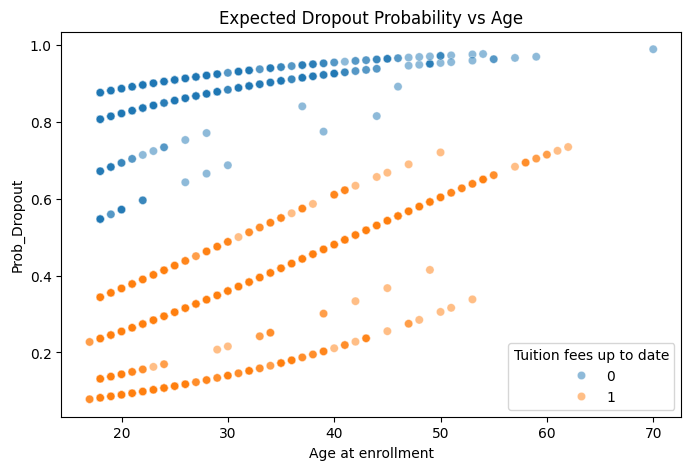


Average prob difference (Tuition 0 vs 1): 0.6181006153586197

Logistic Confusion Matrix:
[[2841  162]
 [ 891  530]]
Logistic Accuracy: 0.7619801084990958


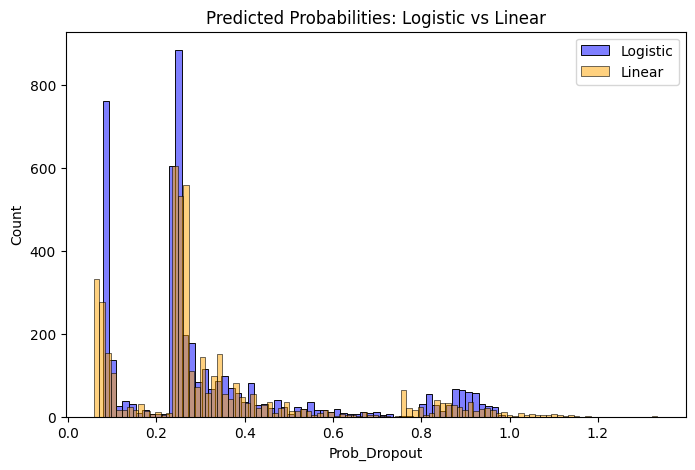

    Dropout  Enrolled  Graduate
0  0.680560  0.210486  0.108954
1  0.706615  0.145494  0.147892
2  0.954343  0.040341  0.005316
3  0.117346  0.176786  0.705867
4  0.183691  0.212551  0.603758
5  0.306501  0.325748  0.367751
6  0.071581  0.140405  0.788013
7  0.954343  0.040341  0.005316
8  0.117346  0.176786  0.705867
9  0.842458  0.122371  0.035170
            Dropout     Enrolled     Graduate
count  4.424000e+03  4424.000000  4424.000000
mean   3.212317e-01     0.179437     0.499331
std    2.874259e-01     0.066652     0.288179
min    9.354861e-07     0.000276     0.001954
25%    1.173462e-01     0.140405     0.172788
50%    1.836911e-01     0.176786     0.603758
75%    5.897361e-01     0.212551     0.705867
max    9.607453e-01     0.330229     0.999723

Multinomial Confusion Matrix:
col_0     Dropout  Graduate
Target                     
Dropout      1054       367
Enrolled      280       514
Graduate      146      2063

Classes explicitly predicted as hard classifications: ['Dropou

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score

df = pd.read_csv('/content/data.csv', sep=';')
cols = ['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment', 'Curricular units 1st sem (approved)', 'Target']
df = df[cols].dropna()

df['Dropout_Binary'] = (df['Target'] == 'Dropout').astype(int)

X_log = df[['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']]
y_log = df['Dropout_Binary']

log_model = LogisticRegression(penalty=None, max_iter=5000)
log_model.fit(X_log, y_log)

print("Logistic Coefficients:")
for col, coef in zip(X_log.columns, log_model.coef_):
    print(f"{col}: {coef}")

df['Prob_Dropout'] = log_model.predict_proba(X_log)[:, 1]

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Age at enrollment', y='Prob_Dropout', hue='Tuition fees up to date', alpha=0.5)
plt.title("Expected Dropout Probability vs Age")
plt.show()

avg_diff = df[df['Tuition fees up to date'] == 0]['Prob_Dropout'].mean() - df[df['Tuition fees up to date'] == 1]['Prob_Dropout'].mean()
print(f"\nAverage prob difference (Tuition 0 vs 1): {avg_diff}")

y_pred_log = log_model.predict(X_log)
print("\nLogistic Confusion Matrix:")
print(confusion_matrix(y_log, y_pred_log))
print(f"Logistic Accuracy: {accuracy_score(y_log, y_pred_log)}")

lin_model = LinearRegression()
lin_model.fit(X_log, y_log)
df['Lin_Prob'] = lin_model.predict(X_log)

plt.figure(figsize=(8, 5))
sns.histplot(df['Prob_Dropout'], color='blue', alpha=0.5, label='Logistic')
sns.histplot(df['Lin_Prob'], color='orange', alpha=0.5, label='Linear')
plt.title("Predicted Probabilities: Logistic vs Linear")
plt.legend()
plt.show()

X_multi = df[['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']]
y_multi = df['Target']

multi_model = LogisticRegression(penalty=None, max_iter=5000, multi_class='multinomial')
multi_model.fit(X_multi, y_multi)

proba_multi = multi_model.predict_proba(X_multi)
proba_df = pd.DataFrame(proba_multi, columns=multi_model.classes_)
print(proba_df.head(10))
print(proba_df.describe())

y_pred_multi = multi_model.predict(X_multi)
print("\nMultinomial Confusion Matrix:")
print(pd.crosstab(y_multi, y_pred_multi))

print(f"\nClasses explicitly predicted as hard classifications: {np.unique(y_pred_multi)}")

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

1. Missing values were dropped
2. Drug has a negative coefficent, meaning that it doesnt not meaningfully improve survival over placebo, as they have very similar survival probabilities Billrubin has a strong negative coefficient, meaning that higher bilrubin does strongly predict lower survival. Edema also has negative coeffficents across categories, meaning that with edema, you have lower predicted survival than those without
4.

Logistic Coefficients:
Bilirubin: [-0.35038135 -0.5785508  -2.85932199  0.25265669]


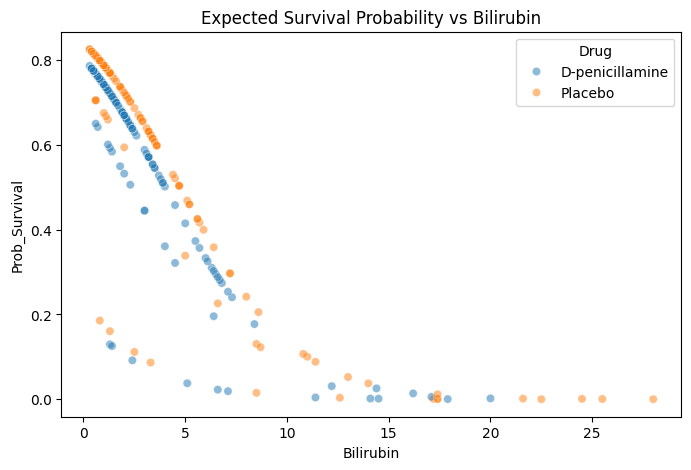


Average survival probabilities:
Drug
D-penicillamine    0.588616
Placebo            0.610393
Name: Prob_Survival, dtype: float64

Logistic Confusion Matrix:
[[ 57  68]
 [ 14 173]]
Logistic Accuracy: 0.7371794871794872


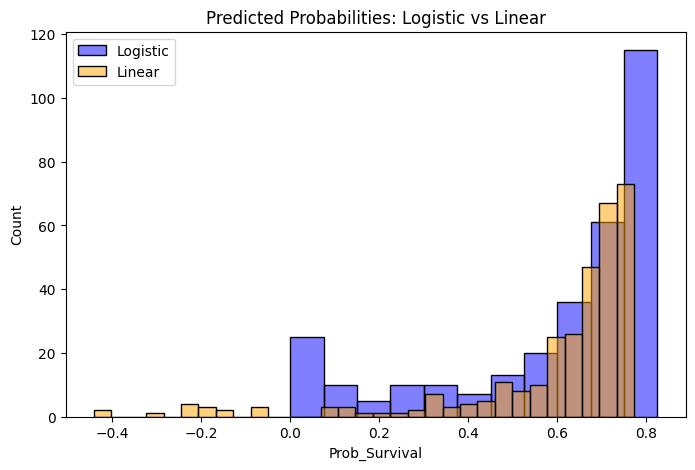


Multinomial Confusion Matrix:
col_0  3.0  4.0
Stage          
1.0     16    0
2.0     61    6
3.0    102   18
4.0     74   35

Classes explicitly predicted: [3. 4.]


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score

df = pd.read_csv('cirrhosis.csv')
cols = ['Bilirubin', 'Edema', 'Drug', 'Stage', 'Status']
df = df[cols].dropna()

df['Survival'] = df['Status'].isin(['C', 'CL']).astype(int)

X_log = pd.get_dummies(df[['Edema', 'Drug', 'Bilirubin']], drop_first=True, dtype=float)
y_log = df['Survival']

log_model = LogisticRegression(penalty=None, max_iter=5000)
log_model.fit(X_log, y_log)

print("Logistic Coefficients:")
for col, coef in zip(X_log.columns, log_model.coef_):
    print(f"{col}: {coef}")

df['Prob_Survival'] = log_model.predict_proba(X_log)[:, 1]

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Bilirubin', y='Prob_Survival', hue='Drug', alpha=0.5)
plt.title("Expected Survival Probability vs Bilirubin")
plt.show()

avg_surv = df.groupby('Drug')['Prob_Survival'].mean()
print(f"\nAverage survival probabilities:\n{avg_surv}")

y_pred_log = log_model.predict(X_log)
print("\nLogistic Confusion Matrix:")
print(confusion_matrix(y_log, y_pred_log))
print(f"Logistic Accuracy: {accuracy_score(y_log, y_pred_log)}")

lin_model = LinearRegression()
lin_model.fit(X_log, y_log)
df['Lin_Prob'] = lin_model.predict(X_log)

plt.figure(figsize=(8, 5))
sns.histplot(df['Prob_Survival'], color='blue', alpha=0.5, label='Logistic')
sns.histplot(df['Lin_Prob'], color='orange', alpha=0.5, label='Linear')
plt.title("Predicted Probabilities: Logistic vs Linear")
plt.legend()
plt.show()

X_multi = pd.get_dummies(df[['Edema', 'Bilirubin']], drop_first=True, dtype=float)
y_multi = df['Stage']

multi_model = LogisticRegression(penalty=None, max_iter=5000)
multi_model.fit(X_multi, y_multi)

y_pred_multi = multi_model.predict(X_multi)
print("\nMultinomial Confusion Matrix:")
print(pd.crosstab(y_multi, y_pred_multi))
print(f"\nClasses explicitly predicted: {np.unique(y_pred_multi)}")

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?